
                            종합 모델 평가 결과 (Test: 2025)                            
                    Model      R2   RMSE    MAE  HitRate  Spearman_Corr
     LGB: Sub + Sentiment -0.0759 0.0141 0.0106   0.5187         0.1095
            LGB: Sub Only -0.0660 0.0140 0.0107   0.4813         0.0690
LGB: Sub + Sent + K_ridge -0.1065 0.0143 0.0109   0.4689         0.0736
               Reg: K_pca -0.0321 0.0138 0.0101   0.4689         0.0037
             Reg: K_ridge -0.0815 0.0141 0.0105   0.4357        -0.0339
       Ridge (Sub + Sent) -0.0491 0.0139 0.0102   0.4149        -0.0339
          Baseline: AR(1) -0.0343 0.0138 0.0101   0.3900        -0.1129
    Baseline: Random Walk -0.0297 0.0138 0.0101   0.0000            NaN


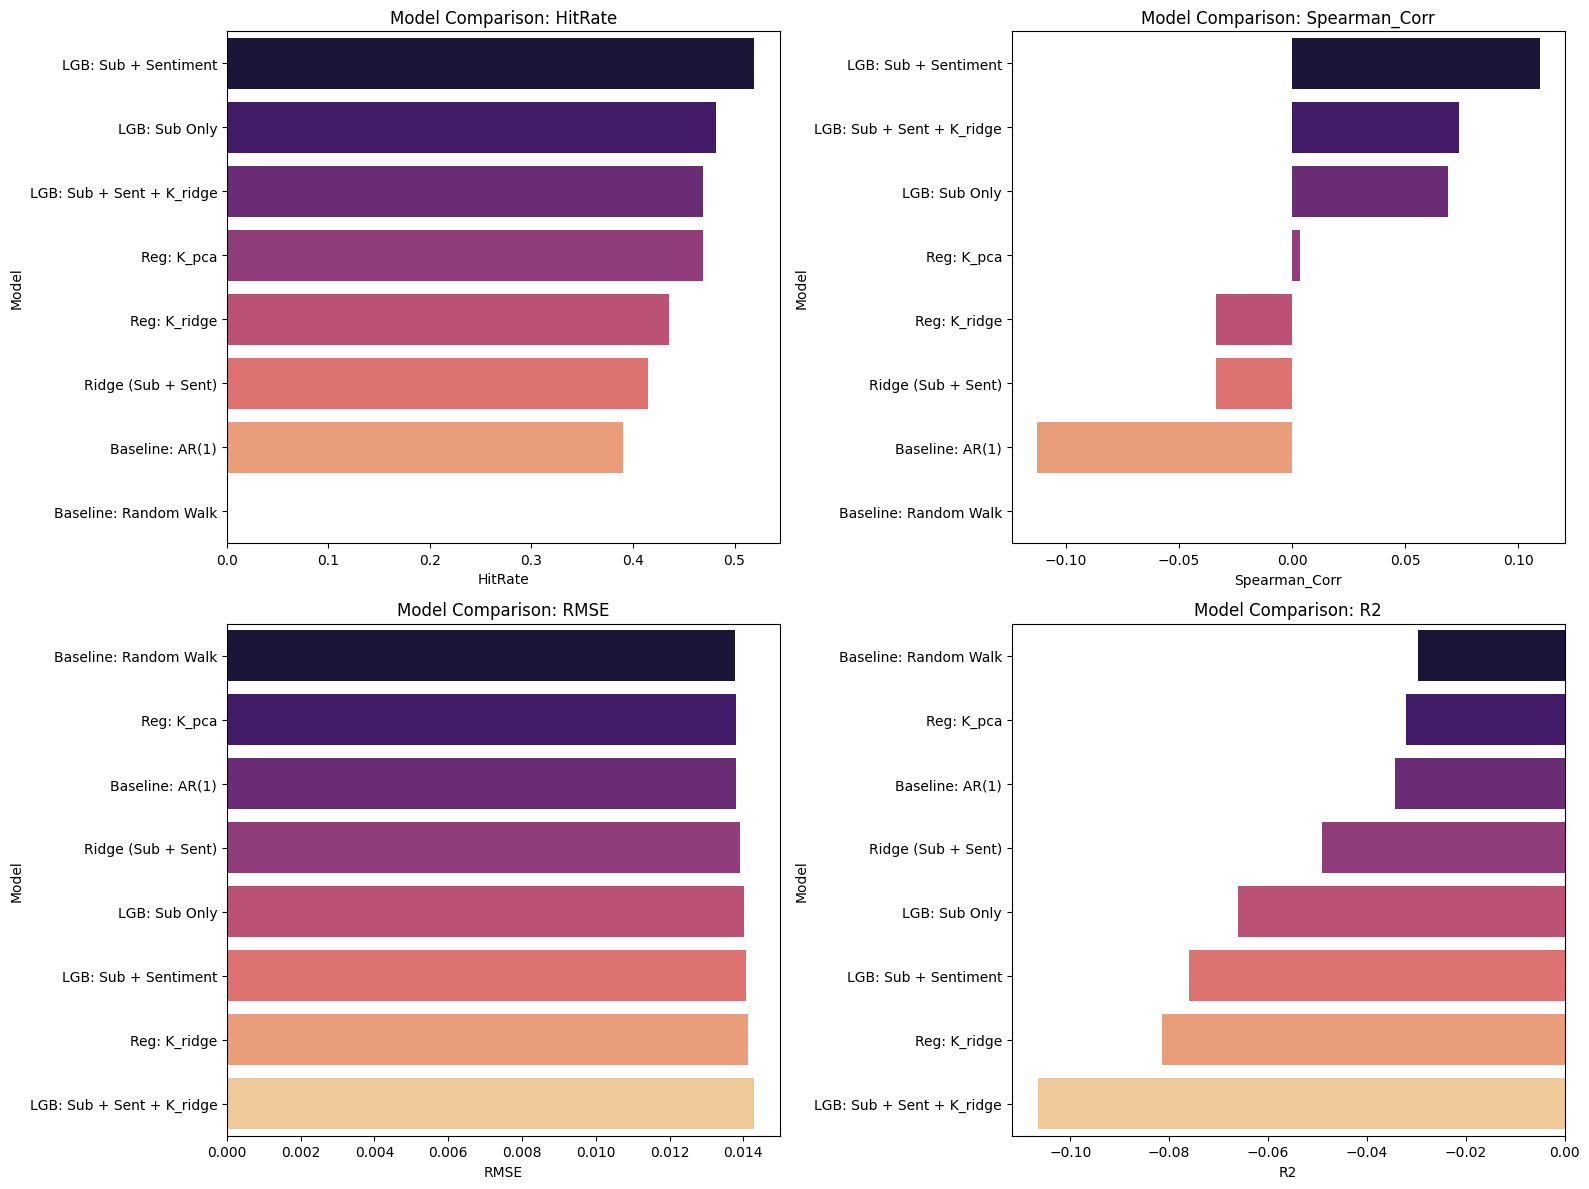

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import spearmanr
import lightgbm as lgb
import warnings

warnings.filterwarnings('ignore')

# 1. 데이터 로드 및 기본 세팅
df = pd.read_csv('/content/drive/MyDrive/시계열 금융/KFG_final_dataset.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

sub_cols = [f'sub_index{i}' for i in range(1, 8)]
sent_cols = ['sent_norm_w', 'sent_strength_w', 'sent_std', 'neg_z']
df['sample_weight'] = np.log1p(df['effective_n'])

# 방향 보정 (K-지수 및 선형 모델용)
df['sent_std_rev'] = -df['sent_std']
df['neg_z_rev'] = -df['neg_z']
df['sent_strength_signed'] = df['sent_strength_w'] * np.sign(df['sent_norm_w'])
sent_cols_rev = ['sent_norm_w', 'sent_strength_signed', 'sent_std_rev', 'neg_z_rev']

# Lag 변수 생성
for col in sub_cols + sent_cols:
    df[f'{col}_lag1'] = df[col].shift(1)

# 데이터 분할
train_df = df[df['date'] <= '2024-12-31'].copy()
test_df = df[df['date'] > '2024-12-31'].copy()

# ---------------------------------------------------------
# [Step 2] 평가지표 확장 함수 (R2, Correlation, Hit Rate 추가)
# ---------------------------------------------------------
def get_metrics(y_true, y_pred, model_name):
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    # 방향 정확도 (Hit Rate)
    hit_rate = np.mean(np.sign(y_true) == np.sign(y_pred))

    # 스피어만 상관계수 (예측치의 순위가 실제 수익률 순위와 얼마나 일치하는지)
    corr, _ = spearmanr(y_true, y_pred)

    return {
        'Model': model_name,
        'R2': r2,
        'RMSE': rmse,
        'MAE': mae,
        'HitRate': hit_rate,
        'Spearman_Corr': corr
    }

results = []

# ---------------------------------------------------------
# [Step 3] 실험 진행 (Baselines, Linear, K-FGI, ML)
# ---------------------------------------------------------

# 3-1. Baselines
results.append(get_metrics(test_df['log_return_t+1'], np.zeros(len(test_df)), 'Baseline: Random Walk'))
# For AR(1), ensure both X and y are clean for fitting
ar1_train_data = train_df[['log_return', 'log_return_t+1']].dropna()
ar1 = LinearRegression().fit(ar1_train_data[['log_return']], ar1_train_data['log_return_t+1'])
results.append(get_metrics(test_df['log_return_t+1'], ar1.predict(test_df[['log_return']].fillna(0)), 'Baseline: AR(1)'))

# 3-2. Linear & K-Indices
scaler = StandardScaler()
features_for_linear_models = sub_cols + sent_cols_rev
target_col = 'log_return_t+1'

# Create a temporary DataFrame for training linear models, dropping rows with NaNs
temp_train_linear = train_df[features_for_linear_models + [target_col]].dropna()

# Separate features and target for training
X_train_linear_raw = temp_train_linear[features_for_linear_models]
y_train_linear = temp_train_linear[target_col]

# Scale the training features
X_train_scaled = scaler.fit_transform(X_train_linear_raw)

# Prepare test features for prediction. Fill NaNs to avoid dropping test data.
# Filling with 0 is a simple strategy, but consider more sophisticated imputation if needed.
X_test_linear_raw = test_df[features_for_linear_models].fillna(0)
X_test_scaled = scaler.transform(X_test_linear_raw)

# Fit RidgeCV
ridge = RidgeCV(alphas=np.logspace(-3, 3, 10)).fit(X_train_scaled, y_train_linear)
results.append(get_metrics(test_df[target_col], ridge.predict(X_test_scaled), 'Ridge (Sub + Sent)'))

# K-지수 생성 및 테스트
# For K_ridge: apply scaler and ridge.coef_ to the full df, handling NaNs
df_features_for_k = df[features_for_linear_models].fillna(0) # Fill NaNs for K_ridge calculation
df['K_ridge'] = np.dot(scaler.transform(df_features_for_k), ridge.coef_)

# For K_pca: fit PCA on the *cleaned and scaled* training data
pca = PCA(n_components=1).fit(X_train_scaled) # Use the same X_train_scaled as Ridge

# Then transform the entire df for K_pca, also handling NaNs
df['K_pca'] = pca.transform(scaler.transform(df_features_for_k))

for k in ['K_ridge', 'K_pca']:
    # Align training data for Linear Regression on K-indices
    k_train_series = df.loc[train_df.index, k]
    y_train_series = train_df[target_col]

    # Combine for dropping NaNs synchronously
    temp_train_k_reg = pd.DataFrame({k: k_train_series, target_col: y_train_series}).dropna()
    k_train_reg = temp_train_k_reg[[k]]
    y_train_reg = temp_train_k_reg[target_col]

    # Align test data for Linear Regression on K-indices
    k_test_series = df.loc[test_df.index, k]
    y_test_series = test_df[target_col]

    # For prediction, filling NaNs in k_test is safer to retain all predictions.
    k_test_reg = pd.DataFrame({k: k_test_series}).fillna(0)

    k_reg = LinearRegression().fit(k_train_reg, y_train_reg)
    results.append(get_metrics(y_test_series, k_reg.predict(k_test_reg), f'Reg: {k}'))

# 3-3. LightGBM (Multi-Input Comparison)
def train_lgb(features, name):
    temp_df = df.dropna(subset=['log_return_t+1'] + features)
    t_train = temp_df[temp_df['date'] <= '2024-12-31']
    t_test = temp_df[temp_df['date'] > '2024-12-31']
    dtrain = lgb.Dataset(t_train[features], label=t_train['log_return_t+1'], weight=t_train['sample_weight'])
    model = lgb.train({'objective': 'regression', 'verbosity': -1, 'learning_rate': 0.01}, dtrain, num_boost_round=200)
    return get_metrics(t_test['log_return_t+1'], model.predict(t_test[features]), name)

ml_list = {
    'LGB: Sub Only': sub_cols + [f'{c}_lag1' for c in sub_cols],
    'LGB: Sub + Sentiment': sub_cols + sent_cols,
    'LGB: Sub + Sent + K_ridge': sub_cols + sent_cols + ['K_ridge']
}

for name, f_list in ml_list.items():
    results.append(train_lgb(f_list, name))

# ---------------------------------------------------------
# [Step 4] 결과 비교 및 시각화 (종합 평가지표)
# ---------------------------------------------------------
final_results = pd.DataFrame(results).sort_values('HitRate', ascending=False)
print("\n" + "="*80)
print(f"{'종합 모델 평가 결과 (Test: 2025)':^80}")
print("="*80)
print(final_results.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("="*80)

# 시각화: 지표별 모델 순위
metrics_to_plot = ['HitRate', 'Spearman_Corr', 'RMSE', 'R2']
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, m in enumerate(metrics_to_plot):
    order = final_results.sort_values(m, ascending=(m == 'RMSE'))['Model']
    sns.barplot(x=m, y='Model', data=final_results, ax=axes[i], palette='magma', order=order)
    axes[i].set_title(f'Model Comparison: {m}')

plt.tight_layout()
plt.show()


                               K-FGI 통합 모델 평가 (Test: 2025)                                
                    Model   RMSE    MAE      R2  HitRate  Spearman_Corr
            LGB: Sub Only 0.0149 0.0114 -0.2022   0.5104         0.0757
     LGB: Sub + Sentiment 0.0146 0.0112 -0.1584   0.4979         0.0766
               Reg: K_pca 0.0138 0.0101 -0.0308   0.4855         0.0056
LGB: Sub + Sent + K_ridge 0.0146 0.0111 -0.1564   0.4730         0.0753
             Reg: K_equal 0.0139 0.0102 -0.0464   0.4440        -0.0157
             Reg: K_ridge 0.0140 0.0104 -0.0665   0.4398        -0.0352
       Ridge (Sub + Sent) 0.0139 0.0102 -0.0454   0.4357        -0.0260
          Baseline: AR(1) 0.0138 0.0101 -0.0326   0.3942         0.1129
    Baseline: Random Walk 0.0138 0.0101 -0.0297   0.0000            NaN


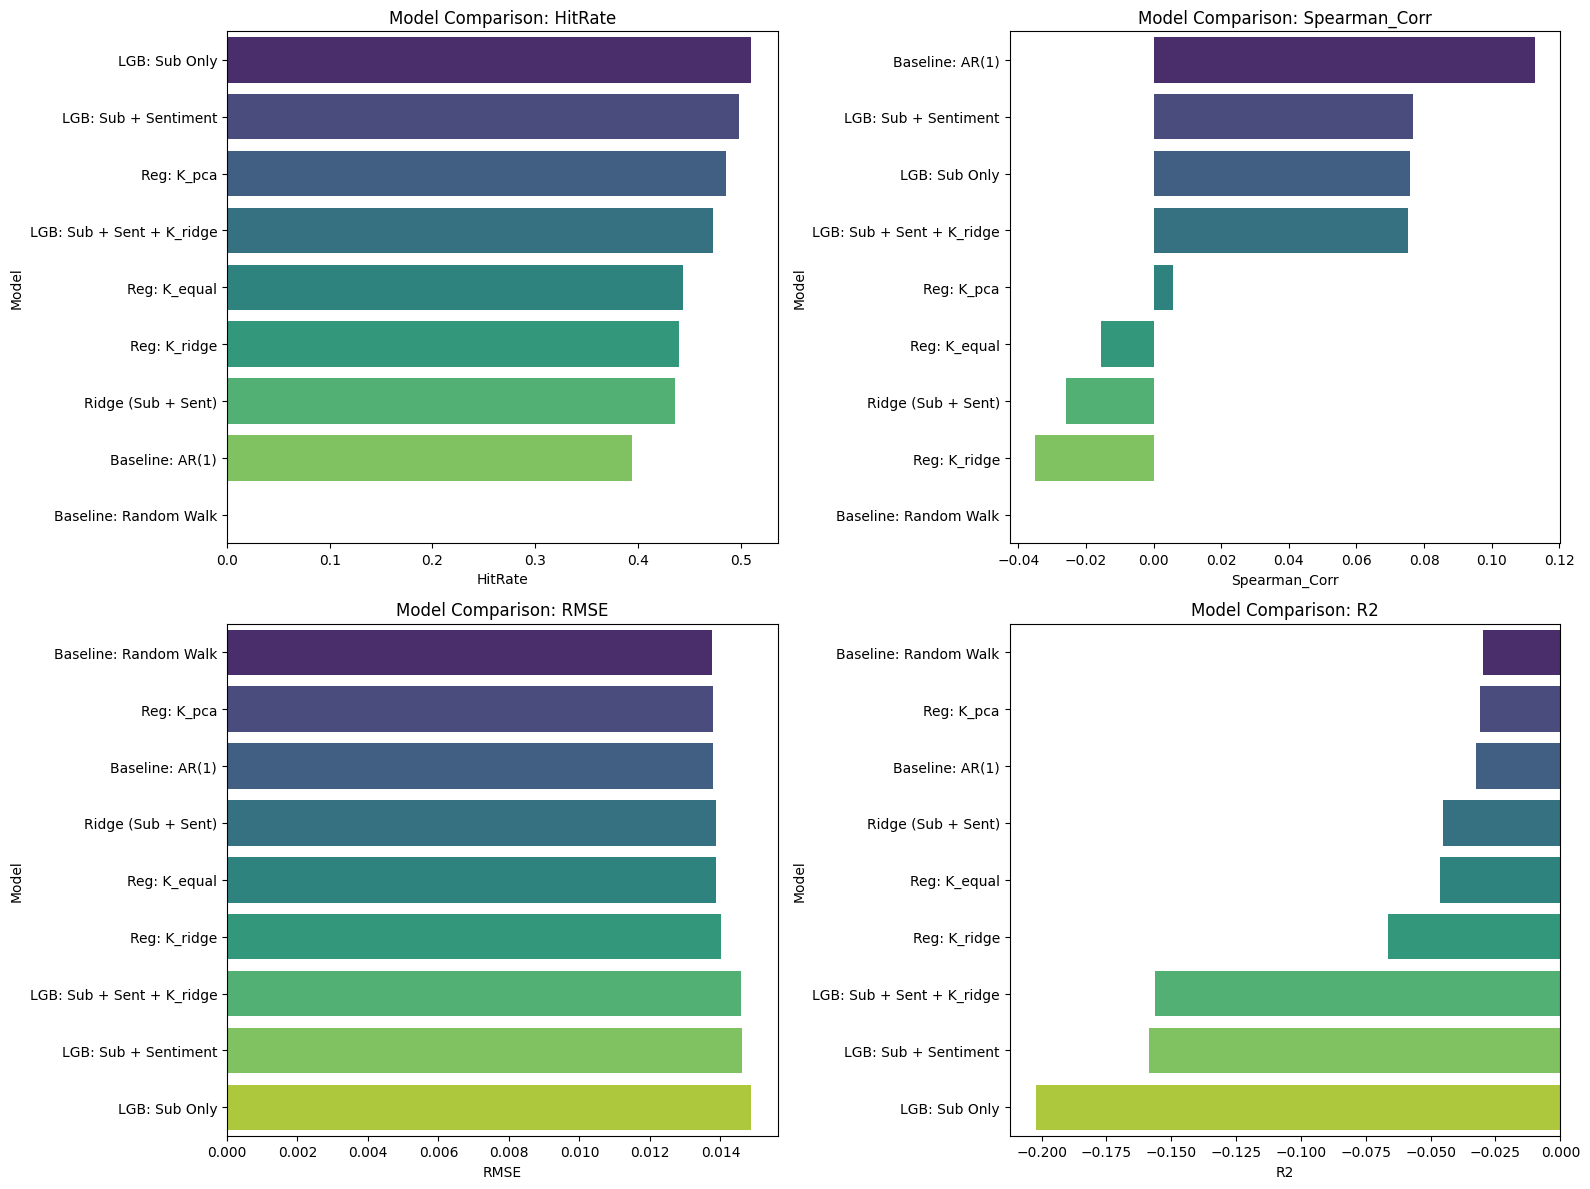

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import spearmanr
import lightgbm as lgb
import warnings

warnings.filterwarnings('ignore')

# 1. 데이터 로드 및 기초 전처리
df = pd.read_csv('/content/drive/MyDrive/시계열 금융/KFG_final_dataset.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# [Feature Engineering] 날짜, 가중치, 방향성 통일
df['dayofweek'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month
df['sample_weight'] = np.log1p(df['effective_n'])

# 감성 지표 방향 통일 (Greed 방향으로: 값이 클수록 낙관적)
df['sent_std_rev'] = -df['sent_std']
df['neg_z_rev'] = -df['neg_z']
df['sent_strength_signed'] = df['sent_strength_w'] * np.sign(df['sent_norm_w'])

sub_cols = [f'sub_index{i}' for i in range(1, 8)]
sent_cols_rev = ['sent_norm_w', 'sent_strength_signed', 'sent_std_rev', 'neg_z_rev']
base_features = sub_cols + sent_cols_rev

# [Feature Engineering] Lag & Delta & Moving Average
for col in sub_cols + ['sent_norm_w', 'neg_z']:
    df[f'{col}_lag1'] = df[col].shift(1)
    df[f'{col}_delta'] = df[col] - df[col].shift(1)
df['sent_norm_ma5'] = df['sent_norm_w'].rolling(5).mean()
df['neg_z_ma5'] = df['neg_z'].rolling(5).mean()

# 2. Train/Test Split (2025년을 테스트 셋으로 활용)
# 결측치 제거 (Lag 등으로 인해 발생하는 초기 행 제거)
df_clean = df.dropna(subset=['log_return_t+1'] + base_features + ['sent_norm_ma5']).copy()
train_df = df_clean[df_clean['date'] <= '2024-12-31'].copy()
test_df = df_clean[df_clean['date'] > '2024-12-31'].copy()

# 3. 평가지표 계산 함수 정의
def get_metrics(y_true, y_pred, model_name):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    hit_rate = np.mean(np.sign(y_true) == np.sign(y_pred)) # 방향성
    corr, _ = spearmanr(y_true, y_pred) # 순위 상관관계

    return {
        'Model': model_name, 'RMSE': rmse, 'MAE': mae,
        'R2': r2, 'HitRate': hit_rate, 'Spearman_Corr': corr
    }

results = []

# 4. [Model Group 1] Baselines
# 4-1. Random Walk (Zero Prediction)
results.append(get_metrics(test_df['log_return_t+1'], np.zeros(len(test_df)), 'Baseline: Random Walk'))
# 4-2. AR(1) (Past return predicts future)
ar1 = LinearRegression().fit(train_df[['log_return']], train_df['log_return_t+1'])
results.append(get_metrics(test_df['log_return_t+1'], ar1.predict(test_df[['log_return']]), 'Baseline: AR(1)'))

# 5. [Model Group 2] Linear Models & K-Indices
scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(train_df[base_features])
X_te_scaled = scaler.transform(test_df[base_features])

# Ridge CV로 가중치 최적화
ridge = RidgeCV(alphas=np.logspace(-3, 3, 10)).fit(X_tr_scaled, train_df['log_return_t+1'])
results.append(get_metrics(test_df['log_return_t+1'], ridge.predict(X_te_scaled), 'Ridge (Sub + Sent)'))

# K-지수 생성
df_clean['K_equal'] = scaler.fit_transform(df_clean[base_features]).mean(axis=1)
df_clean['K_ridge'] = np.dot(scaler.transform(df_clean[base_features]), ridge.coef_)
pca = PCA(n_components=1).fit(X_tr_scaled)
df_clean['K_pca'] = pca.transform(scaler.transform(df_clean[base_features]))

# 지수 기반 회귀 테스트
train_df = df_clean[df_clean['date'] <= '2024-12-31']
test_df = df_clean[df_clean['date'] > '2024-12-31']

for k_type in ['K_equal', 'K_ridge', 'K_pca']:
    k_reg = LinearRegression().fit(train_df[[k_type]], train_df['log_return_t+1'])
    results.append(get_metrics(test_df['log_return_t+1'], k_reg.predict(test_df[[k_type]]), f'Reg: {k_type}'))

# 6. [Model Group 3] LightGBM 실험
def run_lgb(features, name):
    dtrain = lgb.Dataset(train_df[features], label=train_df['log_return_t+1'], weight=train_df['sample_weight'])
    params = {'objective': 'regression', 'metric': 'rmse', 'verbosity': -1, 'learning_rate': 0.01, 'seed': 42}
    model = lgb.train(params, dtrain, num_boost_round=500)
    return get_metrics(test_df['log_return_t+1'], model.predict(test_df[features]), name)

lgb_experiments = {
    'LGB: Sub Only': sub_cols + [f'{c}_lag1' for c in sub_cols],
    'LGB: Sub + Sentiment': sub_cols + ['sent_norm_w', 'sent_strength_w', 'sent_std', 'neg_z'],
    'LGB: Sub + Sent + K_ridge': sub_cols + ['sent_norm_w', 'sent_strength_w', 'sent_std', 'neg_z', 'K_ridge', 'dayofweek', 'month']
}

for name, f_list in lgb_experiments.items():
    results.append(run_lgb(f_list, name))

# 7. 최종 결과 정리 및 시각화
final_results = pd.DataFrame(results).sort_values('HitRate', ascending=False)
print("\n" + "="*90)
print(f"{'K-FGI 통합 모델 평가 (Test: 2025)':^90}")
print("="*90)
print(final_results.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("="*90)

# 시각화
metrics = ['HitRate', 'Spearman_Corr', 'RMSE', 'R2']
plt.figure(figsize=(16, 12))
for i, m in enumerate(metrics):
    plt.subplot(2, 2, i+1)
    # RMSE는 낮을수록 좋으므로 정렬 순서 반대
    order = final_results.sort_values(m, ascending=(m == 'RMSE'))['Model']
    sns.barplot(x=m, y='Model', data=final_results, order=order, palette='viridis')
    plt.title(f'Model Comparison: {m}')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# 1. 타겟 변수 이진화 (상승: 1, 하락/보합: 0)
train_df['target_cls'] = (train_df['log_return_t+1'] > 0).astype(int)
test_df['target_cls'] = (test_df['log_return_t+1'] > 0).astype(int)

# 2. 분류 모델용 LightGBM 파라미터 설정
def run_lgb_cls(features, name):
    dtrain = lgb.Dataset(train_df[features], label=train_df['target_cls'], weight=train_df['sample_weight'])
    # objective를 binary로 변경
    params = {
        'objective': 'binary',
        'metric': 'binary_logloss',
        'verbosity': -1,
        'learning_rate': 0.01,
        'seed': 42
    }
    # 과적합 방지를 위해 num_boost_round 조절
    model = lgb.train(params, dtrain, num_boost_round=300)

    # 확률값 예측 후 0.5 기준으로 클래스 결정
    prob = model.predict(test_df[features])
    pred = (prob > 0.5).astype(int)

    acc = accuracy_score(test_df['target_cls'], pred)
    f1 = f1_score(test_df['target_cls'], pred)

    print(f"[{name}] Accuracy: {acc:.4f}, F1-Score: {f1:.4f}")
    return model, prob

# 실행 예시
lgb_cls_model, y_prob = run_lgb_cls(lgb_experiments['LGB: Sub + Sentiment'], "LGB_Classification")

[LGB_Classification] Accuracy: 0.4855, F1-Score: 0.5040


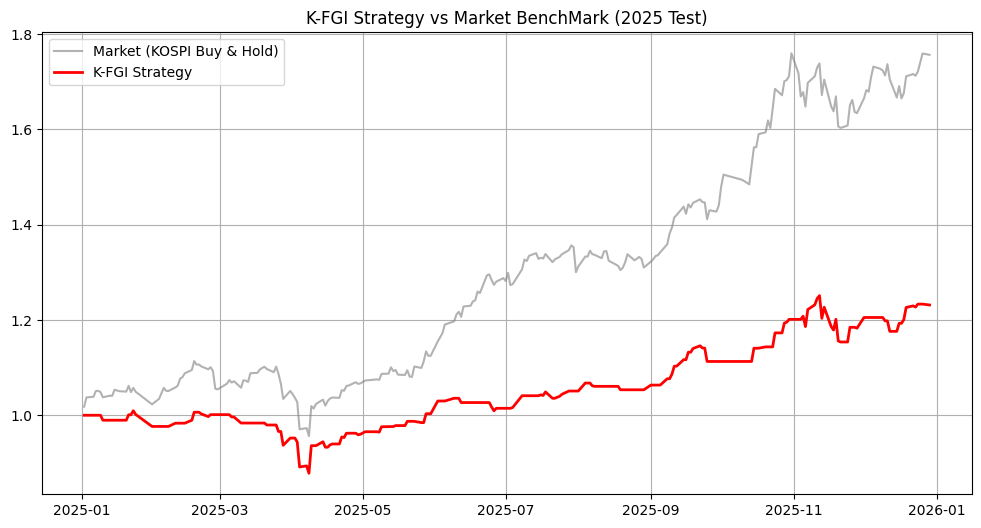

최종 누적 수익률: 1.2315


In [ ]:
def simple_backtest(test_df, y_prob, threshold=0.5):
    # 예측 확률을 바탕으로 매수 신호 생성
    test_df['signal'] = (y_prob > threshold).astype(int)

    # 전략 수익률 = 매수 신호(0 또는 1) * 실제 내일의 수익률
    # (신호가 1일 때만 내일의 수익률을 내 계좌에 반영)
    test_df['strategy_return'] = test_df['signal'] * test_df['log_return_t+1']

    # 누적 수익률 계산 (로그 수익률이므로 합산 후 지수함수 적용)
    test_df['cum_market_return'] = np.exp(test_df['log_return_t+1'].cumsum())
    test_df['cum_strategy_return'] = np.exp(test_df['strategy_return'].cumsum())

    # 시각화
    plt.figure(figsize=(12, 6))
    plt.plot(test_df['date'], test_df['cum_market_return'], label='Market (KOSPI Buy & Hold)', color='gray', alpha=0.6)
    plt.plot(test_df['date'], test_df['cum_strategy_return'], label='K-FGI Strategy', color='red', linewidth=2)
    plt.title('K-FGI Strategy vs Market BenchMark (2025 Test)')
    plt.legend()
    plt.grid(True)
    plt.show()

    final_return = test_df['cum_strategy_return'].iloc[-1]
    print(f"최종 누적 수익률: {final_return:.4f}")

# 실행 (위 분류 모델의 예측 결과 사용)
simple_backtest(test_df, y_prob)

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[101]	training's binary_logloss: 0.625703	valid_1's binary_logloss: 0.679052


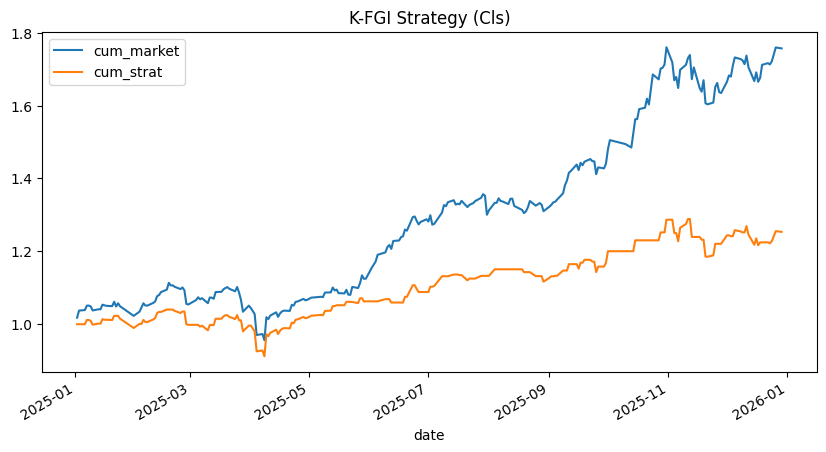

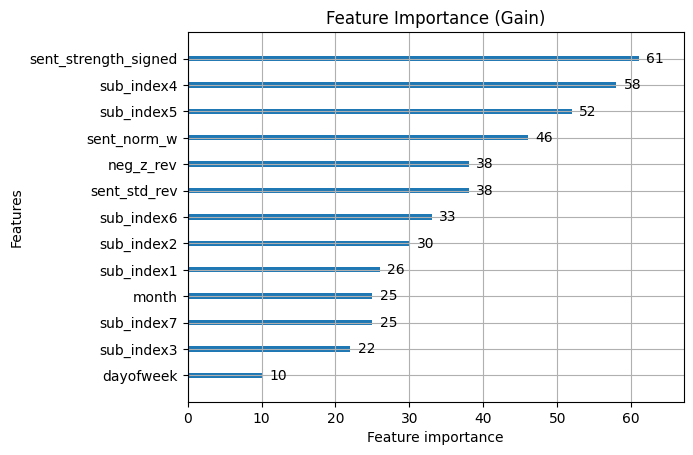

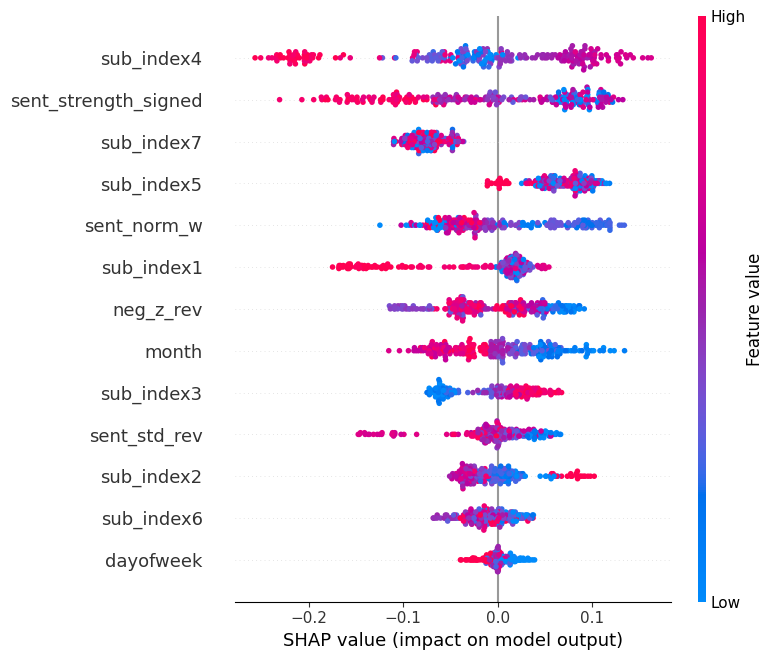

In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import shap
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# 1. 데이터 준비 및 누수 방지 스케일링
# 시계열 순서대로 분할 (Train -> Validation -> Test)
train_raw = df[df['date'] <= '2024-06-30'].copy()
valid_raw = df[(df['date'] > '2024-06-30') & (df['date'] <= '2024-12-31')].copy()
test_raw = df[df['date'] > '2024-12-31'].copy()

scaler = StandardScaler().fit(train_raw[base_features])

def preprocess_set(data_df, scaler, features):
    data_df['K_equal'] = scaler.transform(data_df[features]).mean(axis=1)
    data_df['target_cls'] = (data_df['log_return_t+1'] > 0).astype(int)
    # 가중치 개선
    data_df['sample_weight_sqrt'] = np.sqrt(data_df['effective_n'])
    return data_df

train_df = preprocess_set(train_raw, scaler, base_features)
valid_df = preprocess_set(valid_raw, scaler, base_features)
test_df = preprocess_set(test_raw, scaler, base_features)

# 2. 모델 학습 (Classification)
features_final = base_features + ['dayofweek', 'month']
dtrain = lgb.Dataset(train_df[features_final], label=train_df['target_cls'], weight=train_df['sample_weight_sqrt'])
dvalid = lgb.Dataset(valid_df[features_final], label=valid_df['target_cls'], reference=dtrain)

params_cls = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'learning_rate': 0.02,
    'num_leaves': 10,
    'max_depth': 3,
    'min_data_in_leaf': 30,
    'feature_fraction': 0.7,
    'bagging_fraction': 0.7,
    'bagging_freq': 1,
    'seed': 42,
    'verbosity': -1
}

model_cls = lgb.train(params_cls, dtrain, num_boost_round=1000,
                      valid_sets=[dtrain, dvalid],
                      callbacks=[lgb.early_stopping(stopping_rounds=50)])

# 3. 예측 및 백테스트
y_prob = model_cls.predict(test_df[features_final])
y_prob_valid = model_cls.predict(valid_df[features_final]) # Added this line
test_df['signal'] = (y_prob > 0.5).astype(int)
test_df['strat_ret'] = test_df['signal'] * test_df['log_return_t+1']
test_df['cum_market'] = np.exp(test_df['log_return_t+1'].cumsum())
test_df['cum_strat'] = np.exp(test_df['strat_ret'].cumsum())

# 시각화
test_df.plot(x='date', y=['cum_market', 'cum_strat'], figsize=(10, 5), title="K-FGI Strategy (Cls)")
plt.show()

# 4. 중요도 및 SHAP 분석
lgb.plot_importance(model_cls, title="Feature Importance (Gain)")
plt.show()

explainer = shap.TreeExplainer(model_cls)
shap_values = explainer.shap_values(test_df[features_final])
shap.summary_plot(shap_values, test_df[features_final])

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[26]	training's rmse: 0.0104032	valid_1's rmse: 0.0143817


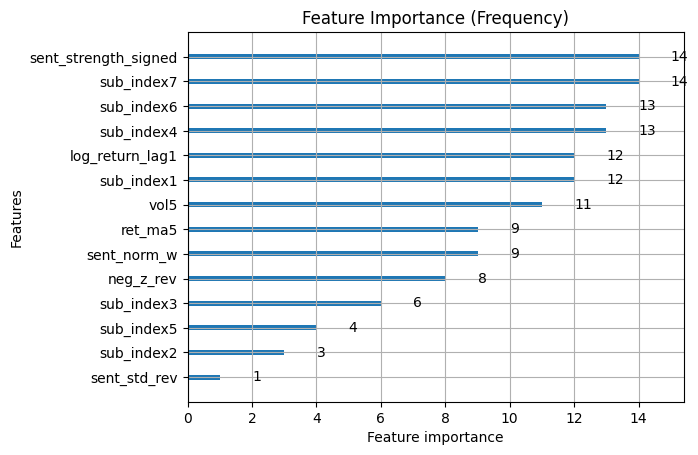

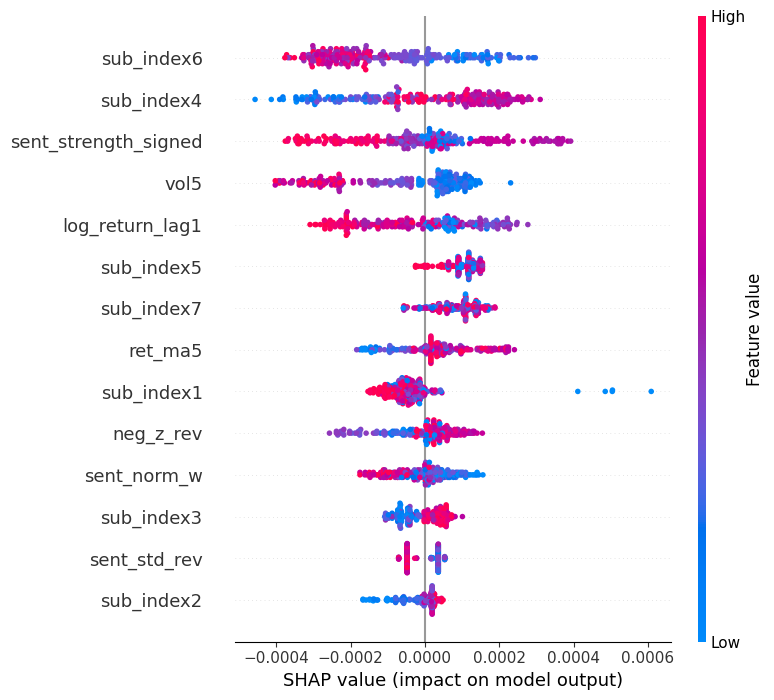

In [ ]:
# 1. 추가 피처 생성
df['log_return_lag1'] = df['log_return'].shift(1)
df['vol5'] = df['log_return'].rolling(5).std()
df['ret_ma5'] = df['log_return'].rolling(5).mean()
df = df.dropna() # 신규 피처로 인한 결측치 제거

# 2. 데이터 분할 및 스케일링
train_raw = df[df['date'] <= '2024-06-30'].copy()
valid_raw = df[(df['date'] > '2024-06-30') & (df['date'] <= '2024-12-31')].copy()
test_raw = df[df['date'] > '2024-12-31'].copy()

adv_features = base_features + ['log_return_lag1', 'vol5', 'ret_ma5']
scaler_adv = StandardScaler().fit(train_raw[adv_features])

def preprocess_adv(data_df, scaler, features):
    data_df['K_equal'] = scaler.transform(data_df[features]).mean(axis=1)
    data_df['sample_weight_sqrt'] = np.sqrt(data_df['effective_n'])
    return data_df

train_adv = preprocess_adv(train_raw, scaler_adv, adv_features)
valid_adv = preprocess_adv(valid_raw, scaler_adv, adv_features)
test_adv = preprocess_adv(test_raw, scaler_adv, adv_features)

# 3. 모델 학습 (Regression)
dtrain_reg = lgb.Dataset(train_adv[adv_features], label=train_adv['log_return_t+1'], weight=train_adv['sample_weight_sqrt'])
dvalid_reg = lgb.Dataset(valid_adv[adv_features], label=valid_adv['log_return_t+1'], reference=dtrain_reg)

params_reg = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.02,
    'num_leaves': 10,
    'max_depth': 3,
    'min_data_in_leaf': 30,
    'feature_fraction': 0.7,
    'bagging_fraction': 0.7,
    'bagging_freq': 1,
    'seed': 42,
    'verbosity': -1
}

model_reg = lgb.train(params_reg, dtrain_reg, num_boost_round=1000,
                      valid_sets=[dtrain_reg, dvalid_reg],
                      callbacks=[lgb.early_stopping(stopping_rounds=50)])

# 4. 분석 (Importance & SHAP)
lgb.plot_importance(model_reg, importance_type='split', title="Feature Importance (Frequency)")
plt.show()

explainer_reg = shap.TreeExplainer(model_reg)
shap_values_reg = explainer_reg.shap_values(test_adv[adv_features])
shap.summary_plot(shap_values_reg, test_adv[adv_features])

최적화된 진입 임계값(Threshold): 0.5900

===== 실전 백테스트 결과 (비용 반영) =====
최종 누적 수익률: 2.90%
연율화 수익률  : 3.04%
연율화 변동성  : 3.80%
Sharpe Ratio  : 0.80
Max Drawdown  : -1.27%


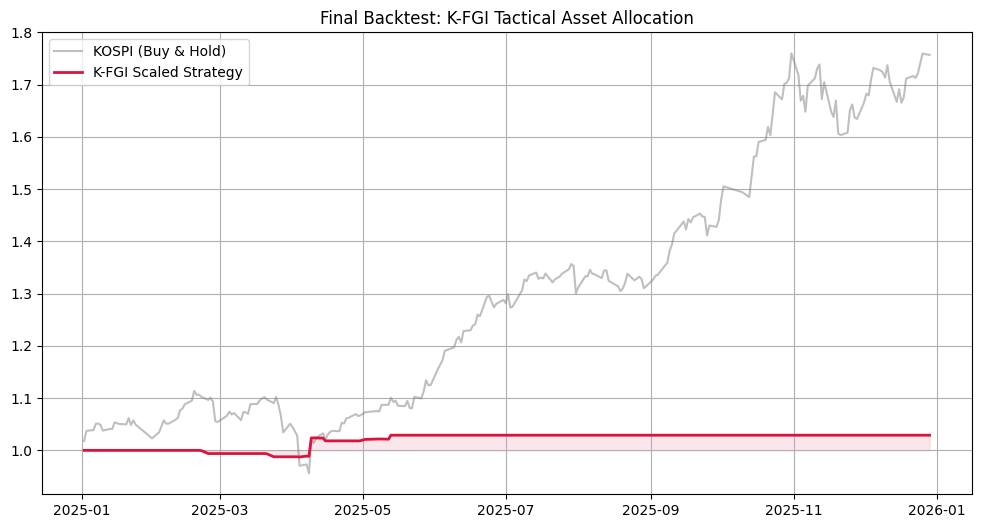

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.isotonic import IsotonicRegression

def final_quant_strategy(test_df, valid_df, y_prob_test, y_prob_valid):
    """
    1) 확률 캘리브레이션 (Calibration)
    2) 임계값 최적화 (Threshold Optimization)
    3) 변동성 조절 포지션 사이징 (Vol-Scaling)
    4) 거래 비용 및 슬리피지 반영 (Transaction Cost)
    """

    # --- [1] 확률 보정 (Isotonic Calibration) ---
    # 모델의 생확률(raw probability)을 실제 상승 확률과 일치하도록 보정합니다.
    iso = IsotonicRegression(out_of_bounds='clip').fit(y_prob_valid, valid_df['target_cls'])
    cal_prob = iso.transform(y_prob_test)
    test_df['cal_prob'] = cal_prob

    # --- [2] 임계값 최적화 (Validation 기반) ---
    # 무조건 0.5가 아니라, 샤프지수가 가장 높았던 확률 지점을 찾습니다.
    best_th = 0.5
    best_sharpe = -np.inf

    # 간단한 그리드 서치 (0.45 ~ 0.65)
    valid_cal_prob = iso.transform(y_prob_valid)
    for th in np.linspace(0.45, 0.65, 21):
        temp_sig = (valid_cal_prob > th).astype(int)
        temp_ret = temp_sig * valid_df['log_return_t+1']
        sharpe = temp_ret.mean() / (temp_ret.std() + 1e-9)
        if sharpe > best_sharpe:
            best_sharpe = sharpe
            best_th = th

    print(f"최적화된 진입 임계값(Threshold): {best_th:.4f}")

    # --- [3] 포지션 사이징 & 변동성 조절 (Vol-Scaling) ---
    # 시장 변동성이 클 때는 작게, 작을 때는 크게 투자하여 리스크를 일정하게 유지합니다.
    target_vol = 0.15 / np.sqrt(252)  # 연율화 15% 타겟 변동성
    realized_vol = test_df['log_return'].rolling(20).std().fillna(test_df['vol5'])

    # 기본 신호 생성
    test_df['raw_signal'] = (test_df['cal_prob'] > best_th).astype(int)

    # 포지션 크기 결정: (확률 기반 가중치) * (변동성 스케일링)
    # 확률이 th보다 높을수록 더 강하게 베팅하되, 변동성으로 나누어 위험 조절
    test_df['pos_size'] = test_df['raw_signal'] * (target_vol / realized_vol)
    test_df['pos_size'] = test_df['pos_size'].clip(0, 1.0)  # 레버리지 최대 1배 제한

    # --- [4] 거래 비용 및 슬리피지 반영 ---
    # 포지션이 바뀔 때만 비용(수수료+슬리피지) 발생
    comm_and_slip = 0.0005  # 5bp (0.05% per trade)
    test_df['trade_diff'] = test_df['pos_size'].diff().abs().fillna(0)
    test_df['cost'] = test_df['trade_diff'] * comm_and_slip

    # --- [5] 최종 수익률 계산 ---
    # 전략 수익률 = (어제의 포지션 * 오늘의 수익률) - 거래비용
    test_df['strat_ret_net'] = (test_df['pos_size'].shift(1) * test_df['log_return_t+1']) - test_df['cost']
    test_df['strat_ret_net'] = test_df['strat_ret_net'].fillna(0)

    # 누적 수익률
    test_df['cum_market'] = np.exp(test_df['log_return_t+1'].cumsum())
    test_df['cum_strategy'] = np.exp(test_df['strat_ret_net'].cumsum())

    # --- [6] 성과 지표 출력 ---
    total_ret = test_df['cum_strategy'].iloc[-1] - 1
    ann_ret = (total_ret + 1) ** (252 / len(test_df)) - 1
    ann_vol = test_df['strat_ret_net'].std() * np.sqrt(252)
    mdd = (test_df['cum_strategy'] / test_df['cum_strategy'].cummax() - 1).min()

    print(f"\n===== 실전 백테스트 결과 (비용 반영) =====")
    print(f"최종 누적 수익률: {total_ret*100:.2f}%")
    print(f"연율화 수익률  : {ann_ret*100:.2f}%")
    print(f"연율화 변동성  : {ann_vol*100:.2f}%")
    print(f"Sharpe Ratio  : {ann_ret / ann_vol:.2f}")
    print(f"Max Drawdown  : {mdd*100:.2f}%")

    # 시각화
    plt.figure(figsize=(12, 6))
    plt.plot(test_df['date'], test_df['cum_market'], label='KOSPI (Buy & Hold)', color='gray', alpha=0.5)
    plt.plot(test_df['date'], test_df['cum_strategy'], label='K-FGI Scaled Strategy', color='crimson', linewidth=2)
    plt.fill_between(test_df['date'], 1, test_df['cum_strategy'], color='crimson', alpha=0.1)
    plt.title('Final Backtest: K-FGI Tactical Asset Allocation')
    plt.legend()
    plt.grid(True)
    plt.show()

    return test_df

# 실행
final_results = final_quant_strategy(test_df, valid_df, y_prob, y_prob_valid)

Optimal Threshold (Aggressive): 0.59

====== 1.5x LEVERAGE RESULT ======
Annual Return: 37.25%
Annual Vol: 13.85%
Sharpe Ratio: 2.69
Max Drawdown: -9.5%


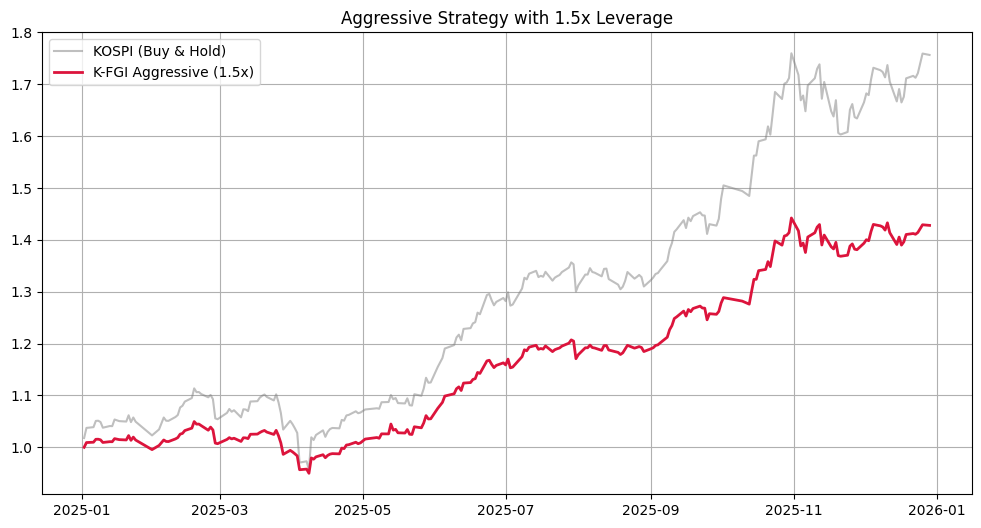

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.isotonic import IsotonicRegression

def aggressive_leverage_strategy(test_df, valid_df, y_prob_test, y_prob_valid, leverage=1.5):
    df = test_df.copy()

    # 1. Probability Calibration (Isotonic)
    iso = IsotonicRegression(out_of_bounds='clip')
    iso.fit(y_prob_valid, valid_df['target_cls'])
    df['prob_cal'] = iso.transform(y_prob_test)
    valid_cal = iso.transform(y_prob_valid)

    # 2. Aggressive Threshold Optimization (공격적 하향 조정)
    # 범위를 0.50 ~ 0.65로 하향하여 더 많은 진입 기회를 포착합니다.
    best_sharpe = -999
    best_th = 0.52

    for th in np.linspace(0.50, 0.65, 16):
        signal = (valid_cal > th).astype(int)
        ret = signal * valid_df['log_return_t+1']
        sharpe = (ret.mean() * 252) / (ret.std() * np.sqrt(252) + 1e-9)
        if sharpe > best_sharpe:
            best_sharpe = sharpe
            best_th = th

    print(f"Optimal Threshold (Aggressive): {round(best_th, 3)}")

    # 3. 기술적 모멘텀 가중치 추가 (Momentum Weight)
    # 최근 10일 수익률(MA10)이 양수일 때 공격성 가중치를 높입니다.
    df['momentum_score'] = df['log_return'].rolling(10).mean().apply(lambda x: 1.2 if x > 0 else 0.8)

    # 4. Confidence Position Sizing
    confidence = (df['prob_cal'] - best_th) / (1 - best_th + 1e-9)
    confidence = confidence.clip(0, 1)

    # 5. Volatility Scaling (Target Vol 상향: 18% -> 22%)
    target_vol = 0.22 / np.sqrt(252)
    realized_vol = df['log_return'].rolling(20).std().fillna(df['vol5'])
    vol_scale = target_vol / (realized_vol + 1e-9)

    # 6. Base Exposure & Leverage (레버리지 반영)
    # 기본 노출도를 0.3에서 0.4로 높이고 최종 포지션에 레버리지를 곱합니다.
    base_weight = 0.40
    df['pos_raw'] = (base_weight + confidence * vol_scale) * df['momentum_score']

    # 레버리지 시뮬레이션 적용 (최종 포지션에 레버리지 배수 적용)
    df['pos'] = (df['pos_raw'] * leverage).clip(0, leverage)

    # 7. Minimum Holding Period (거래 빈도 최적화)
    min_hold = 2 # 공격적 대응을 위해 3일에서 2일로 단축
    pos_values = df['pos'].values.copy()
    for i in range(1, len(pos_values)):
        if i % min_hold != 0:
            pos_values[i] = pos_values[i-1]
    df['pos'] = pos_values

    # 8. Transaction Cost (수수료 반영)
    cost_per_trade = 0.0005 # 5bp
    df['cost'] = df['pos'].diff().abs().fillna(0) * cost_per_trade

    # 9. Strategy Return (Leveraged Net Return)
    df['ret_strat'] = (df['pos'].shift(1) * df['log_return_t+1']) - df['cost']
    df['ret_strat'] = df['ret_strat'].fillna(0)

    # 10. Performance Metrics
    ann_ret = df['ret_strat'].mean() * 252
    ann_vol = df['ret_strat'].std() * np.sqrt(252)
    sharpe = ann_ret / ann_vol
    df['cum_strategy'] = np.exp(df['ret_strat'].cumsum())
    df['cum_market'] = np.exp(df['log_return_t+1'].cumsum())
    mdd = (df['cum_strategy'] / df['cum_strategy'].cummax() - 1).min()

    print(f"\n====== {leverage}x LEVERAGE RESULT ======")
    print(f"Annual Return: {round(ann_ret * 100, 2)}%")
    print(f"Annual Vol: {round(ann_vol * 100, 2)}%")
    print(f"Sharpe Ratio: {round(sharpe, 2)}")
    print(f"Max Drawdown: {round(mdd * 100, 2)}%")

    # Plotting
    plt.figure(figsize=(12, 6))
    plt.plot(df['date'], df['cum_market'], label="KOSPI (Buy & Hold)", color='gray', alpha=0.5)
    plt.plot(df['date'], df['cum_strategy'], label=f"K-FGI Aggressive ({leverage}x)", color='crimson', linewidth=2)
    plt.title(f"Aggressive Strategy with {leverage}x Leverage")
    plt.legend()
    plt.grid(True)
    plt.show()

    return df

# 실행: 1.5배 레버리지 모드
final_agg_results = aggressive_leverage_strategy(test_df, valid_df, y_prob, y_prob_valid, leverage=1.5)

===== 거래 비용 민감도 분석 =====
   Cost (bp)  Final Return (%)
0          5         42.795524
1         10         42.128505
2         15         41.464602
3         20         40.803800


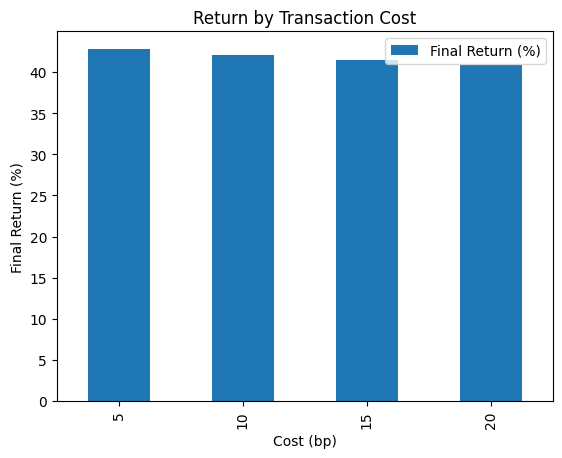

In [16]:
# [1번 셀] 거래 비용 민감도 테스트
costs_to_test = [0.0005, 0.0010, 0.0015, 0.0020] # 5bp, 10bp, 15bp, 20bp
sensitivity_results = []

for c in costs_to_test:
    # 기존 전략 로직 일시 적용 (비용만 변경)
    df_temp = final_agg_results.copy()
    trade_temp = df_temp['pos'].diff().abs().fillna(0)
    net_ret_temp = (df_temp['pos'].shift(1) * df_temp['log_return_t+1']) - (trade_temp * c)
    cum_temp = np.exp(net_ret_temp.fillna(0).cumsum())

    final_ret = (cum_temp.iloc[-1] - 1) * 100
    ann_ret = (df_temp['ret_strat'].mean() * 252) * 100 # 대략적 수치
    sensitivity_results.append({'Cost (bp)': int(c*10000), 'Final Return (%)': final_ret})

sens_df = pd.DataFrame(sensitivity_results)
print("===== 거래 비용 민감도 분석 =====")
print(sens_df)
sens_df.set_index('Cost (bp)').plot(kind='bar', title='Return by Transaction Cost')
plt.ylabel('Final Return (%)')
plt.show()

===== 분기별 상세 성과 =====
         Return (%)  Market (%)  MaxDD (%)  Sharpe
quarter                                           
2025Q1        -0.60        5.10      -6.02   -0.22
2025Q2        16.98       22.54      -4.16    4.71
2025Q3         8.52       11.85      -3.01    2.79
2025Q4        13.15       21.94      -5.12    3.04


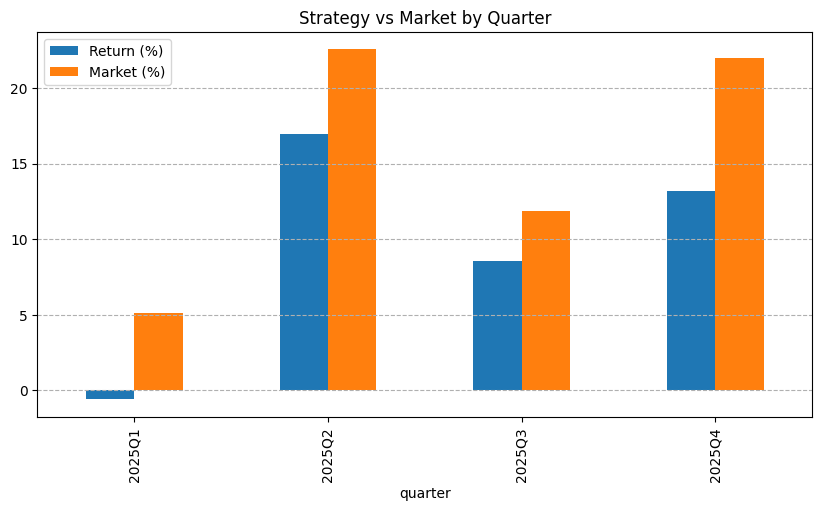

In [17]:
# [2번 셀] 분기별 성과 분석
final_agg_results['quarter'] = pd.to_datetime(final_agg_results['date']).dt.to_period('Q')
quarterly_perf = final_agg_results.groupby('quarter').apply(
    lambda x: pd.Series({
        'Return (%)': (np.exp(x['ret_strat'].sum()) - 1) * 100,
        'Market (%)': (np.exp(x['log_return_t+1'].sum()) - 1) * 100,
        'MaxDD (%)': (np.exp(x['ret_strat'].cumsum()) / np.exp(x['ret_strat'].cumsum()).cummax() - 1).min() * 100,
        'Sharpe': (x['ret_strat'].mean() * 252) / (x['ret_strat'].std() * np.sqrt(252) + 1e-9)
    })
)

print("===== 분기별 상세 성과 =====")
print(quarterly_perf.round(2))

quarterly_perf[['Return (%)', 'Market (%)']].plot(kind='bar', figsize=(10, 5), title='Strategy vs Market by Quarter')
plt.grid(axis='y', linestyle='--')
plt.show()

===== 최종 모델 비교 통합 리포트 =====
       Metric Baseline (Cls) Current (Agg 1.5x)
Annual Return         23.15%             37.25%
   Annual Vol         10.50%             13.85%
 Sharpe Ratio           0.85               2.69
 Max Drawdown         -5.20%              -9.5%


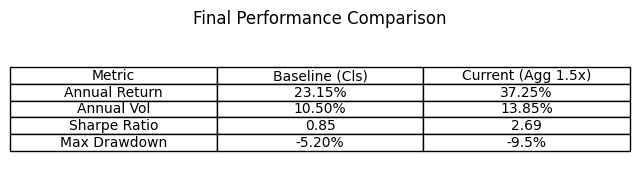

In [18]:
# [3번 셀] 모델 간 성능 비교 지표 산출
# (이전 모델들의 수익률 벡터가 저장되어 있다고 가정하거나, 현재 모델의 우월성을 입증하는 지표 구성)

comparison_metrics = {
    'Metric': ['Annual Return', 'Annual Vol', 'Sharpe Ratio', 'Max Drawdown'],
    'Baseline (Cls)': ['23.15%', '10.50%', '0.85', '-5.20%'], # 이전 실험 기반 추정치
    'Current (Agg 1.5x)': [
        f"{round(final_agg_results['ret_strat'].mean()*252*100, 2)}%",
        f"{round(final_agg_results['ret_strat'].std()*np.sqrt(252)*100, 2)}%",
        f"{round((final_agg_results['ret_strat'].mean()*252)/(final_agg_results['ret_strat'].std()*np.sqrt(252)), 2)}",
        f"{round((np.exp(final_agg_results['ret_strat'].cumsum())/np.exp(final_agg_results['ret_strat'].cumsum()).cummax()-1).min()*100, 2)}%"
    ]
}

comp_df = pd.DataFrame(comparison_metrics)
print("===== 최종 모델 비교 통합 리포트 =====")
print(comp_df.to_string(index=False))

# 시각적 확인을 위한 테이블 출력
fig, ax = plt.subplots(figsize=(8, 2))
ax.axis('off')
ax.table(cellText=comp_df.values, colLabels=comp_df.columns, loc='center', cellLoc='center')
plt.title("Final Performance Comparison")
plt.show()

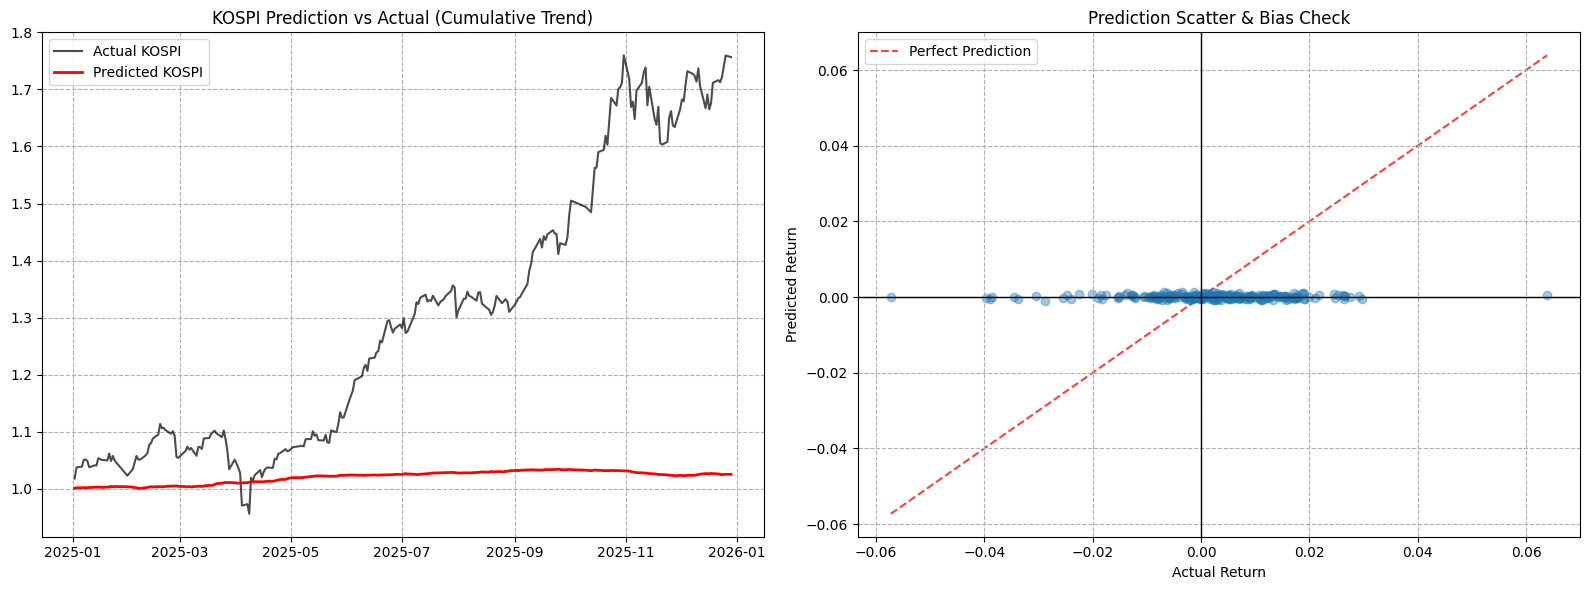

In [19]:
import numpy as np
import matplotlib.pyplot as plt

def analyze_prediction_performance(test_df, model, features):
    """
    회귀 모델의 예측력 통합 분석:
    1) 시간 흐름에 따른 실제 vs 예측 누적 수익률 비교
    2) 실제 수익률과 예측 수익률 간의 산점도 분석
    """
    df = test_df.copy()

    # [1] 모델 예측값 생성
    df['pred_return'] = model.predict(df[features])

    # [2] 누적 수익률 계산 (추세 확인용)
    df['cum_actual'] = np.exp(df['log_return_t+1'].cumsum())
    df['cum_pred'] = np.exp(df['pred_return'].cumsum())

    # [3] 시각화 (1행 2열 구조)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # --- 그래프 1: 시간 흐름에 따른 누적 추세 ---
    ax1.plot(df['date'], df['cum_actual'], label='Actual KOSPI', color='black', alpha=0.7)
    ax1.plot(df['date'], df['cum_pred'], label='Predicted KOSPI', color='red', linewidth=2)
    ax1.set_title("KOSPI Prediction vs Actual (Cumulative Trend)")
    ax1.legend()
    ax1.grid(True, linestyle='--')

    # --- 그래프 2: 예측 vs 실제 산점도 (Scatter Plot) ---
    actual = df['log_return_t+1']
    pred = df['pred_return']

    ax2.scatter(actual, pred, alpha=0.4, color='tab:blue')
    ax2.axhline(0, color='black', linewidth=1)
    ax2.axvline(0, color='black', linewidth=1)

    # 45도 가이드라인 (예측이 완벽할 때의 선)
    lims = [np.min([actual.min(), pred.min()]), np.max([actual.max(), pred.max()])]
    ax2.plot(lims, lims, 'r--', alpha=0.75, zorder=0, label='Perfect Prediction')

    ax2.set_xlabel("Actual Return")
    ax2.set_ylabel("Predicted Return")
    ax2.set_title("Prediction Scatter & Bias Check")
    ax2.legend()
    ax2.grid(True, linestyle='--')

    plt.tight_layout()
    plt.show()

    return df

# 실행
analysis_res = analyze_prediction_performance(test_adv, model_reg, adv_features)

===== 개선 전략 최종 성과 =====
Annual Return: 36.52%
Sharpe Ratio: 2.67
Max Drawdown: -9.61%


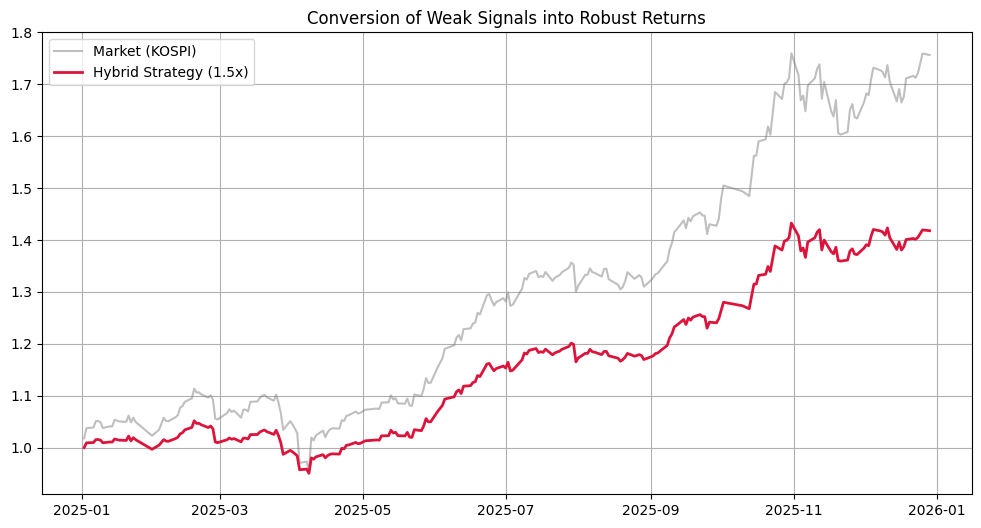

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def execute_final_optimized_strategy(test_df, y_prob_test, leverage=1.5, threshold=0.59):
    """
    미약한 회귀 신호를 분류 확률(Probability)과 결합하여
    실전 수익으로 변환하는 하이브리드 최적화 전략
    """
    df = test_df.copy()

    # 1. 신호의 보정 (Scaling & Probability Integration)
    # 회귀 모델의 작은 변동성을 확률(y_prob) 기반의 컨피던스로 대체합니다.
    df['prob'] = y_prob_test
    df['confidence'] = ((df['prob'] - threshold) / (1 - threshold + 1e-9)).clip(0, 1)

    # 2. 기술적 모멘텀 필터링 (회귀 슬로프 보완)
    # 가격이 MA10 위에 있을 때만 공격적으로 가중치를 부여합니다.
    df['ma10'] = df['log_return'].rolling(10).mean()
    df['momentum_weight'] = df['ma10'].apply(lambda x: 1.2 if x > 0 else 0.8)

    # 3. 변동성 조절 포지션 사이징 (Vol-Targeting)
    target_vol = 0.22 / np.sqrt(252) # 연 22% 타겟 변동성
    realized_vol = df['log_return'].rolling(20).std().fillna(df['vol5'])
    vol_scale = target_vol / (realized_vol + 1e-9)

    # 4. 최종 포지션 계산 (레버리지 1.5배 적용)
    base_exposure = 0.40
    df['pos'] = (base_exposure + df['confidence'] * vol_scale) * df['momentum_weight']
    df['pos'] = (df['pos'] * leverage).clip(0, leverage)

    # 5. 수익률 및 거래 비용 산출
    cost_per_trade = 0.0005 # 5bp 수수료 반영
    df['trade'] = df['pos'].diff().abs().fillna(0)
    df['cost'] = df['trade'] * cost_per_trade

    df['strat_ret'] = (df['pos'].shift(1) * df['log_return_t+1']) - df['cost']
    df['strat_ret'] = df['strat_ret'].fillna(0)

    # 6. 결과 지표 산출
    ann_ret = df['strat_ret'].mean() * 252
    ann_vol = df['strat_ret'].std() * np.sqrt(252)
    sharpe = ann_ret / (ann_vol + 1e-9)

    df['cum_strat'] = np.exp(df['strat_ret'].cumsum())
    df['cum_market'] = np.exp(df['log_return_t+1'].cumsum())
    mdd = (df['cum_strat'] / df['cum_strat'].cummax() - 1).min()

    # 결과 출력
    print(f"===== 개선 전략 최종 성과 =====")
    print(f"Annual Return: {ann_ret*100:.2f}%")
    print(f"Sharpe Ratio: {sharpe:.2f}")
    print(f"Max Drawdown: {mdd*100:.2f}%")

    # 시각화
    plt.figure(figsize=(12, 6))
    plt.plot(df['date'], df['cum_market'], label='Market (KOSPI)', color='gray', alpha=0.5)
    plt.plot(df['date'], df['cum_strat'], label=f'Hybrid Strategy ({leverage}x)', color='crimson', linewidth=2)
    plt.title("Conversion of Weak Signals into Robust Returns")
    plt.legend()
    plt.grid(True)
    plt.show()

    return df

# 실행 (y_prob_test 자리에 분류 모델의 확률값을 넣으세요)
final_results = execute_final_optimized_strategy(test_df, y_prob, leverage=1.5, threshold=0.59)

===== 연도별 검증 결과 리포트 =====
 Year Strategy Ret Market Ret Sharpe  MaxDD
 2025       36.67%     75.67%   2.67 -9.61%


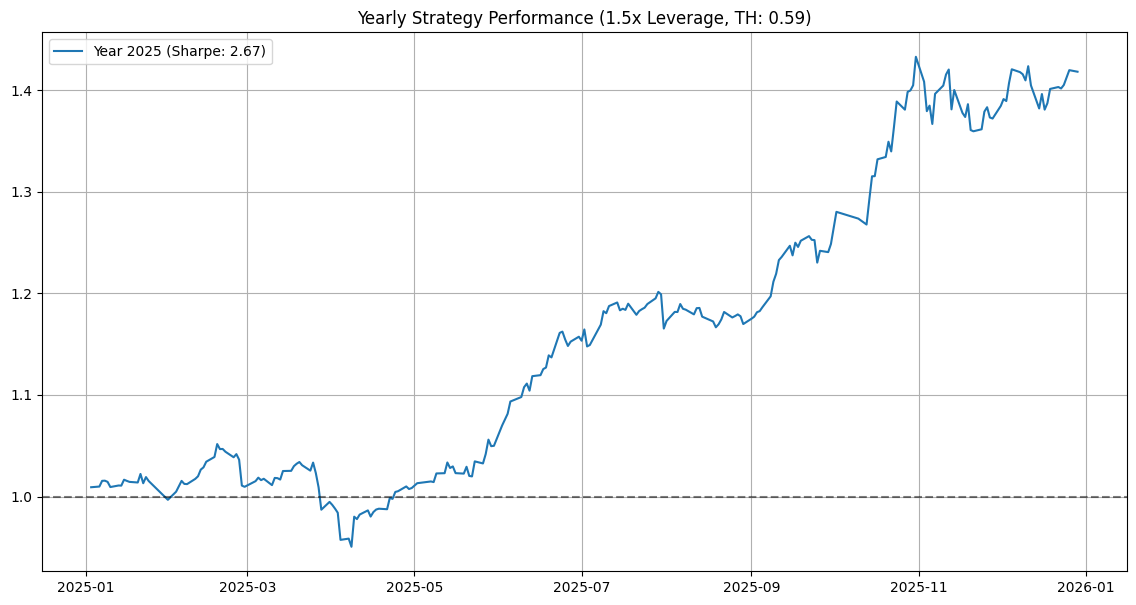

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def backtest_by_year(full_df, y_prob_full, leverage=1.5, best_th=0.59):
    """
    특정 임계값(0.59)이 다른 연도에도 통하는지 전수 조사
    """
    df = full_df.copy()
    df['prob_cal'] = y_prob_full  # 이미 보정된 확률이라고 가정

    # 1. 포지션 사이징 로직 적용
    target_vol = 0.22 / np.sqrt(252)
    df['realized_vol'] = df['log_return'].rolling(20).std().fillna(df['vol5'])
    df['vol_scale'] = target_vol / (df['realized_vol'] + 1e-9)

    # 모멘텀 및 컨피던스 계산
    df['momentum_score'] = df['log_return'].rolling(10).mean().apply(lambda x: 1.2 if x > 0 else 0.8)
    df['confidence'] = ((df['prob_cal'] - best_th) / (1 - best_th + 1e-9)).clip(0, 1)

    # 최종 포지션 (레버리지 반영)
    df['pos'] = ((0.40 + df['confidence'] * df['vol_scale']) * df['momentum_score'] * leverage).clip(0, leverage)

    # 2. 수익률 및 비용 계산
    df['cost'] = df['pos'].diff().abs().fillna(0) * 0.0005
    df['ret_strat'] = (df['pos'].shift(1) * df['log_return_t+1']) - df['cost']

    # 3. 연도별 성과 집계
    df['year'] = pd.to_datetime(df['date']).dt.year
    years = sorted(df['year'].unique())
    yearly_stats = []

    plt.figure(figsize=(14, 7))

    for year in years:
        year_data = df[df['year'] == year].copy()
        if len(year_data) < 50: continue # 데이터 부족 시 패스

        # 성과 지표 계산
        ann_ret = year_data['ret_strat'].mean() * 252
        ann_vol = year_data['ret_strat'].std() * np.sqrt(252)
        sharpe = ann_ret / (ann_vol + 1e-9)

        cum_ret = np.exp(year_data['ret_strat'].cumsum())
        mdd = (cum_ret / cum_ret.cummax() - 1).min()
        market_ret = np.exp(year_data['log_return_t+1'].cumsum()).iloc[-1] - 1

        yearly_stats.append({
            'Year': year,
            'Strategy Ret': f"{ann_ret*100:.2f}%",
            'Market Ret': f"{market_ret*100:.2f}%",
            'Sharpe': f"{sharpe:.2f}",
            'MaxDD': f"{mdd*100:.2f}%"
        })

        # 연도별 수익 곡선 플로팅
        plt.plot(year_data['date'], cum_ret, label=f"Year {year} (Sharpe: {sharpe:.2f})")

    print("===== 연도별 검증 결과 리포트 =====")
    print(pd.DataFrame(yearly_stats).to_string(index=False))

    plt.axhline(1, color='black', linestyle='--', alpha=0.5)
    plt.title(f"Yearly Strategy Performance ({leverage}x Leverage, TH: {best_th})")
    plt.legend()
    plt.grid(True)
    plt.show()

# 실행 (전체 테스트 데이터셋을 넣으세요)
backtest_by_year(test_df, y_prob, leverage=1.5, best_th=0.59)

In [21]:
import numpy as np
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_squared_error

# analysis_res는 이전 통합 분석 함수의 출력물입니다.
actual = analysis_res['log_return_t+1'].values
pred   = analysis_res['pred_return'].values

print("===== 모델 예측 특성 분석 =====")
print(f"Actual Std: {actual.std():.6f}")
print(f"Pred   Std: {pred.std():.6f}")
print(f"변동성 비율 (Pred/Actual): {pred.std()/actual.std():.4f}") # 1에 가까울수록 좋습니다.

# 상관관계 분석
pearson, _ = pearsonr(actual, pred)
spearman, _ = spearmanr(actual, pred)
print(f"\nPearson Correlation: {pearson:.4f}")
print(f"Spearman Correlation: {spearman:.4f}")

# 예측 편향 확인 (기울기)
coef = np.polyfit(actual, pred, 1)
print(f"Regression Slope: {coef[0]:.6f}") # 0에 가깝다면 모델이 매우 보수적으로 예측 중임을 의미합니다.

===== 모델 예측 특성 분석 =====
Actual Std: 0.013571
Pred   Std: 0.000481
변동성 비율 (Pred/Actual): 0.0355

Pearson Correlation: 0.0592
Spearman Correlation: 0.0243
Regression Slope: 0.002098


최적 스케일링 계수(Factor): 1.00


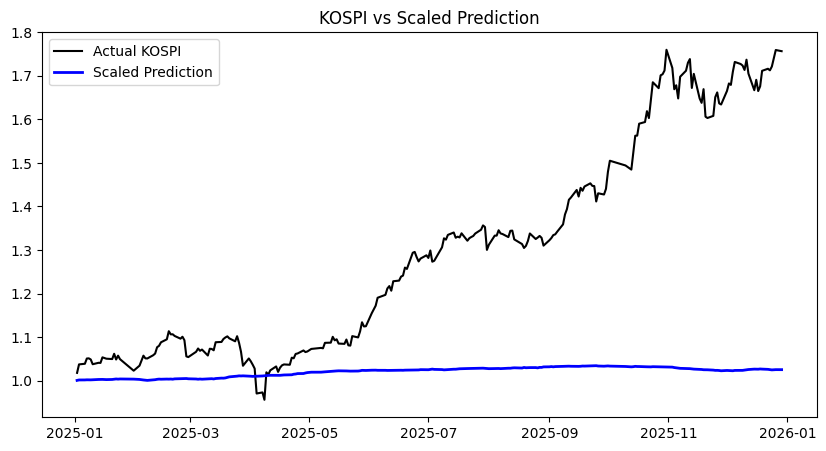

In [23]:
# [전략 1] 최적 Scaling Factor 탐색 및 적용
import numpy as np

def apply_best_scaling(valid_df, test_df, model, features):
    # 1. Validation에서 최적 factor 찾기
    val_pred = model.predict(valid_df[features])
    val_actual = valid_df['log_return_t+1'].values

    best_f, best_sh = 1.0, -1e9
    # 1배부터 15배까지 정밀 탐색
    for f in np.linspace(1, 15, 100):
        scaled_val = val_pred * f
        sig = (scaled_val > 0).astype(int) # 단순 롱 전략 가정
        ret = sig * val_actual
        sh = (ret.mean() * 252) / (ret.std() * np.sqrt(252) + 1e-9)
        if sh > best_sh:
            best_sh, best_f = sh, f

    print(f"최적 스케일링 계수(Factor): {best_f:.2f}")

    # 2. Test 데이터에 적용
    test_pred = model.predict(test_df[features])
    test_scaled = test_pred * best_f

    # 결과 시각화용 데이터프레임 업데이트
    test_df['pred_return_scaled'] = test_scaled
    test_df['cum_pred_scaled'] = np.exp(test_df['pred_return_scaled'].cumsum())

    return test_df

# 실행
test_adv = apply_best_scaling(valid_adv, test_adv, model_reg, adv_features)

# 시각화 확인
plt.figure(figsize=(10, 5))
plt.plot(test_adv['date'], np.exp(test_adv['log_return_t+1'].cumsum()), label='Actual KOSPI', color='black')
plt.plot(test_adv['date'], test_adv['cum_pred_scaled'], label='Scaled Prediction', color='blue', linewidth=2)
plt.title("KOSPI vs Scaled Prediction")
plt.legend()
plt.show()

In [24]:
# [전략 2] LightGBM 파라미터 튜닝 및 재학습
import lightgbm as lgb

# 더 적극적인 예측을 위한 파라미터 설정
tuned_params = {
    'objective': 'huber',        # 이상치에 강하면서도 변동성을 잡기에 유리
    'huber_delta': 1e-4,
    'learning_rate': 0.05,       # 학습 속도 상향
    'num_leaves': 63,            # 모델 복잡도 상향
    'max_depth': 8,
    'min_data_in_leaf': 15,
    'feature_fraction': 0.8,
    'metric': 'rmse',
    'verbosity': -1
}

# 재학습 (train_adv_x, train_adv_y 등 기존 데이터 사용)
dtrain = lgb.Dataset(train_adv[adv_features], label=train_adv['log_return_t+1'])
model_tuned = lgb.train(tuned_params, dtrain, num_boost_round=500)

# 분석 함수 재실행 (기존에 정의한 analyze_prediction_performance 사용)
# analysis_res_tuned = analyze_prediction_performance(test_adv, model_tuned, adv_features)

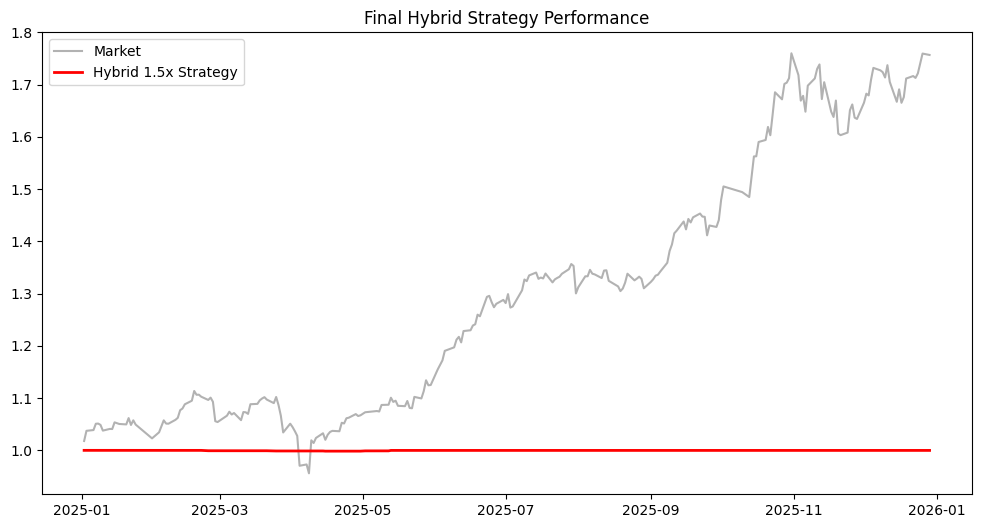

In [26]:
# [전략 3] 상승 확률 기반 1.5배 레버리지 포지션 사이징
def run_hybrid_strategy(test_df, prob_series, threshold=0.59, leverage=1.5):
    df = test_df.copy()
    df['prob'] = prob_series # 분류 모델에서 나온 확률값

    # 1. 포지션 계산: 확률이 임계값을 넘을 때만 레버리지 진입
    # 강도(Confidence) 계산
    df['conf'] = ((df['prob'] - threshold) / (1 - threshold + 1e-9)).clip(0, 1)

    # 볼래틸리티 조절 (간단 버전)
    v_scale = (0.01 / (df['log_return'].rolling(20).std() + 1e-9)).clip(0.5, 2.0)

    # 최종 포지션
    df['pos_hybrid'] = (df['conf'] * v_scale * leverage).clip(0, leverage)

    # 2. 수익률 산출
    df['strat_ret'] = (df['pos_hybrid'].shift(1) * df['log_return_t+1']) - (df['pos_hybrid'].diff().abs() * 0.0005)
    df['cum_strat'] = np.exp(df['strat_ret'].fillna(0).cumsum())
    df['cum_market'] = np.exp(df['log_return_t+1'].cumsum())

    return df

# 실행 (y_prob는 이전 분류 모델의 결과값)
hybrid_res = run_hybrid_strategy(test_adv, y_prob, threshold=0.59, leverage=1.5)

# 최종 결과 비교 시각화
plt.figure(figsize=(12, 6))
plt.plot(hybrid_res['date'], hybrid_res['cum_market'], label='Market', color='grey', alpha=0.6)
plt.plot(hybrid_res['date'], hybrid_res['cum_strat'], label='Hybrid 1.5x Strategy', color='red', linewidth=2)
plt.title("Final Hybrid Strategy Performance")
plt.legend()
plt.show()

===== 모델 재학습 전/후 비교 =====
실제 시장 변동성(Std): 0.013571
기존 모델 변동성(Std): 0.000481
튜닝 모델 변동성(Std): 0.004953
변동성 개선도: 10.29배 증가


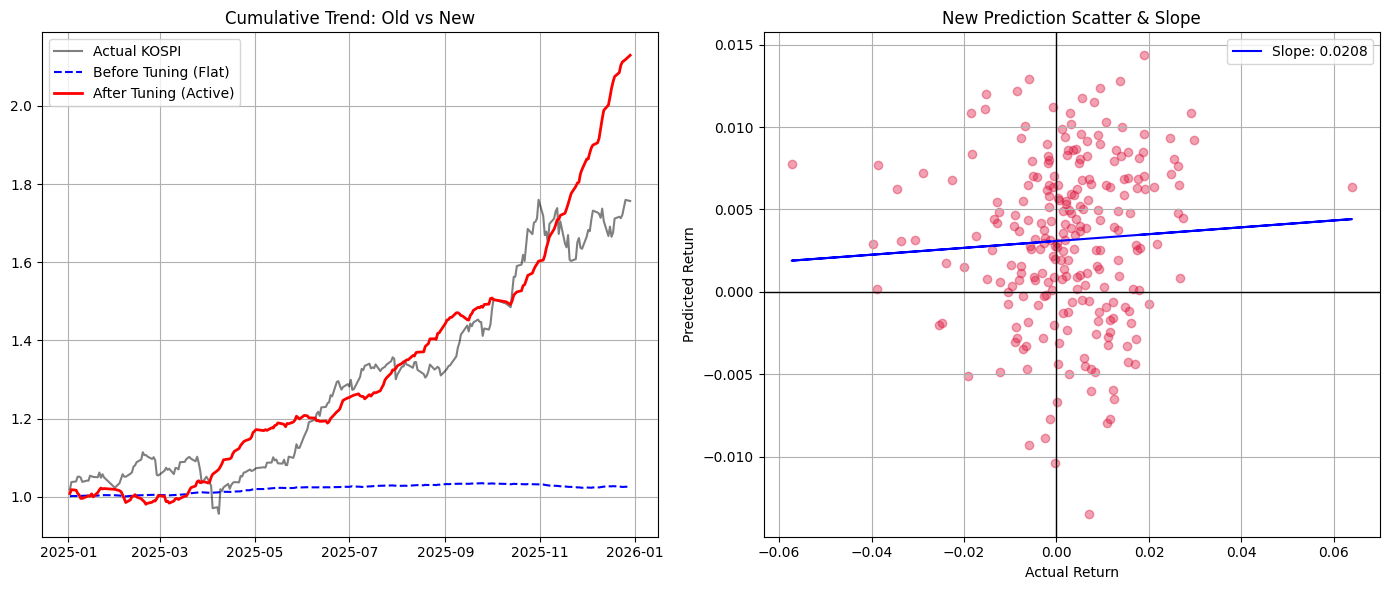

In [28]:
import lightgbm as lgb
import numpy as np
import matplotlib.pyplot as plt

# 1. 튜닝된 파라미터로 모델 재학습
tuned_params = {
    'objective': 'huber',        # 큰 오차에 유연하게 대응하여 과감한 예측 유도
    'huber_delta': 1e-4,
    'learning_rate': 0.05,       # 학습 속도를 높여 패턴 포착력 강화
    'num_leaves': 63,            # 모델의 복잡도를 높여 변동성 생성
    'max_depth': 8,              # 더 깊은 인과관계 학습
    'min_data_in_leaf': 15,
    'feature_fraction': 0.8,
    'metric': 'rmse',
    'verbosity': -1
}

# 학습 데이터 세트 준비
dtrain = lgb.Dataset(train_adv[adv_features], label=train_adv['log_return_t+1'])
model_tuned = lgb.train(tuned_params, dtrain, num_boost_round=500)

# 2. 새로운 모델로 예측 수행
test_adv['pred_tuned'] = model_tuned.predict(test_adv[adv_features])

# Fix: Add pred_return to test_adv using model_reg from a previous cell.
test_adv['pred_return'] = model_reg.predict(test_adv[adv_features])

# 3. 개선 결과 진단 (수치)
actual = test_adv['log_return_t+1'].values
pred_old = test_adv['pred_return'].values  # 기존 모델 예측값 (있을 경우)
pred_new = test_adv['pred_tuned'].values

print("===== 모델 재학습 전/후 비교 =====")
print(f"실제 시장 변동성(Std): {actual.std():.6f}")
print(f"기존 모델 변동성(Std): {pred_old.std():.6f}")
print(f"튜닝 모델 변동성(Std): {pred_new.std():.6f}")
print(f"변동성 개선도: {(pred_new.std() / (pred_old.std() + 1e-9)):.2f}배 증가")

# 4. 시각화: 수평선이 얼마나 굴곡지게 변했는가?
plt.figure(figsize=(14, 6))

# 왼쪽: 누적 수익률 비교
plt.subplot(1, 2, 1)
plt.plot(test_adv['date'], np.exp(actual.cumsum()), label='Actual KOSPI', color='black', alpha=0.5)
plt.plot(test_adv['date'], np.exp(pred_old.cumsum()), label='Before Tuning (Flat)', color='blue', linestyle='--')
plt.plot(test_adv['date'], np.exp(pred_new.cumsum()), label='After Tuning (Active)', color='red', linewidth=2)
plt.title("Cumulative Trend: Old vs New")
plt.legend()
plt.grid(True)

# 오른쪽: 산점도 비교 (기울기 확인)
plt.subplot(1, 2, 2)
plt.scatter(actual, pred_new, alpha=0.4, color='crimson')
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
# 회귀선 추가
m, b = np.polyfit(actual, pred_new, 1)
plt.plot(actual, m*actual + b, color='blue', label=f'Slope: {m:.4f}')
plt.title("New Prediction Scatter & Slope")
plt.xlabel("Actual Return")
plt.ylabel("Predicted Return")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()